In [1]:
from sparkle.api import transform_df, Input, Output
import sparkle
import os

In [2]:
rt = sparkle.SparkleRuntime()
vfs = sparkle.Vfs(rt, {"/myproject/data/testdata": os.path.expanduser("~/git/sparkle/jupyter/testdata")})
rt.start()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/20 15:06:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
#df = rt.spark.read.csv(os.path.expanduser("~/git/sparkle/jupyter/testdata/oscar_age_female.csv"))
#df.toPandas()

In [4]:
#bar = Input("/myproject/data/testdata/oscar_age_female.csv")
#df = rt.load(bar)
#df.toPandas()

In [5]:

#df = rt.load(bar)

In [6]:
from sparkle.api import transform_df, Input, Output
#from transform.api import tranform_df, Input, Output
from pyspark.sql import DataFrame
import pyspark.sql.functions as F
@transform_df(
    Output("/myproject/data/testdata/result2"),
    xx=Input("/myproject/data/testdata/oscar_age_female"),
    xy=Input("/myproject/data/testdata/oscar_age_male")
)
def mytransform(xx : DataFrame, xy : DataFrame):
    return (xx.withColumn('Gender', F.lit('female'))
            .union(xy.withColumn('Gender', F.lit('male')))
            .orderBy(xx.Age))

In [7]:
rt.transforms.clear()
rt.transforms.append(mytransform)
rt.submit()

Reading /myproject/data/testdata/oscar_age_female
Loading /Users/K0SF/git/sparkle/jupyter/testdata/oscar_age_female as None
Reading /myproject/data/testdata/oscar_age_male
Loading /Users/K0SF/git/sparkle/jupyter/testdata/oscar_age_male as None
Saving /Users/K0SF/git/sparkle/jupyter/testdata/result2 as None


In [8]:
df=rt.load(Input("/myproject/data/testdata/result2")).toPandas()

Loading /Users/K0SF/git/sparkle/jupyter/testdata/result2 as None


In [9]:
import matplotlib.pyplot as plt

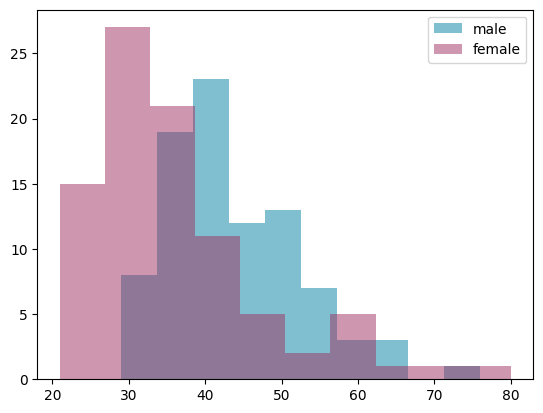

In [10]:
plt.hist(df[df.Gender=='male'].Age.astype(int), alpha=0.5, color='#0080a0', label='male', bins=10)
plt.hist(df[df.Gender=='female'].Age.astype(int), alpha=0.5, color='#a03060', label='female', bins=10)
plt.legend()